# M5 Forecasting 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Day 1: Retail Demand Diagnosis

## 1. Is demand stationary?

...

## 2. Is there weekly seasonality?

...

## 3. Does demand differ by geography?

...

## 4. Does demand differ by product hierarchy?

...

## 5. How severe is intermittent demand?

...

## 6. Are sales concentrated among a small number of series?

...

## 7. Do external signals appear relevant?

Events:
...

SNAP:
...

Price:
...

## 8. What does this mean for forecasting?

...

## 1. Load and inspect the data

In [2]:
DATA_PATH = "../../data/m5-forecasting-accuracy/"

sales = pd.read_csv(
    DATA_PATH + "sales_train_validation.csv"
)

calendar = pd.read_csv(
    DATA_PATH + "calendar.csv"
)

prices = pd.read_csv(
    DATA_PATH + "sell_prices.csv"
)

In [3]:
print("Sales:", sales.shape)
print("Calendar:", calendar.shape)
print("Prices:", prices.shape)

display(sales.head())
display(calendar.head())
display(prices.head())

Sales: (30490, 1919)
Calendar: (1969, 14)
Prices: (6841121, 4)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


## 2. Understand the dataset structure

In [4]:
print(sales.columns[:15].tolist())
print(sales.columns[-10:].tolist())

day_cols = [
    col for col in sales.columns
    if col.startswith("d_")
]

print("Number of historical days:", len(day_cols))
print("Items:", sales["item_id"].nunique())
print("Departments:", sales["dept_id"].nunique())
print("Categories:", sales["cat_id"].nunique())
print("Stores:", sales["store_id"].nunique())
print("States:", sales["state_id"].nunique())
print("Bottom-level series:", len(sales))

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9']
['d_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']
Number of historical days: 1913
Items: 3049
Departments: 7
Categories: 3
Stores: 10
States: 3
Bottom-level series: 30490


## 3. Inspect the hierarchy

In [5]:
hierarchy = (
    sales[
        [
            "state_id",
            "store_id",
            "cat_id",
            "dept_id",
            "item_id"
        ]
    ]
    .drop_duplicates()
)

display(hierarchy.head())

,state_id,store_id,cat_id,dept_id,item_id
0,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_001
1,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_002
2,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_003
3,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_004
4,CA,CA_1,HOBBIES,HOBBIES_1,HOBBIES_1_005


In [6]:
print(
    sales[
        ["state_id", "store_id"]
    ]
    .drop_duplicates()
    .sort_values(["state_id", "store_id"])
)

      state_id store_id
0           CA     CA_1
3049        CA     CA_2
6098        CA     CA_3
9147        CA     CA_4
12196       TX     TX_1
15245       TX     TX_2
18294       TX     TX_3
21343       WI     WI_1
24392       WI     WI_2
27441       WI     WI_3


In [7]:
print(
    sales[
        ["cat_id", "dept_id"]
    ]
    .drop_duplicates()
    .sort_values(["cat_id", "dept_id"])
)

         cat_id      dept_id
1612      FOODS      FOODS_1
1828      FOODS      FOODS_2
2226      FOODS      FOODS_3
0       HOBBIES    HOBBIES_1
416     HOBBIES    HOBBIES_2
565   HOUSEHOLD  HOUSEHOLD_1
1097  HOUSEHOLD  HOUSEHOLD_2


## 4. Calendar prep

In [8]:
calendar["date"] = pd.to_datetime(
    calendar["date"]
)

#Keep only dates corresponding to our training period:

train_calendar = calendar[
    calendar["d"].isin(day_cols)
].copy()

#Check:

print(
    train_calendar["date"].min(),
    train_calendar["date"].max()
)

#Sort:

train_calendar = (
    train_calendar
    .sort_values("date")
    .reset_index(drop=True)
)

2011-01-29 00:00:00 2016-04-24 00:00:00


## 5. Sales over time

,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,d_1,32631,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,d_2,31749,2011-01-30,11101,Sunday,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,d_3,23783,2011-01-31,11101,Monday,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,d_4,25412,2011-02-01,11101,Tuesday,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,d_5,19146,2011-02-02,11101,Wednesday,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


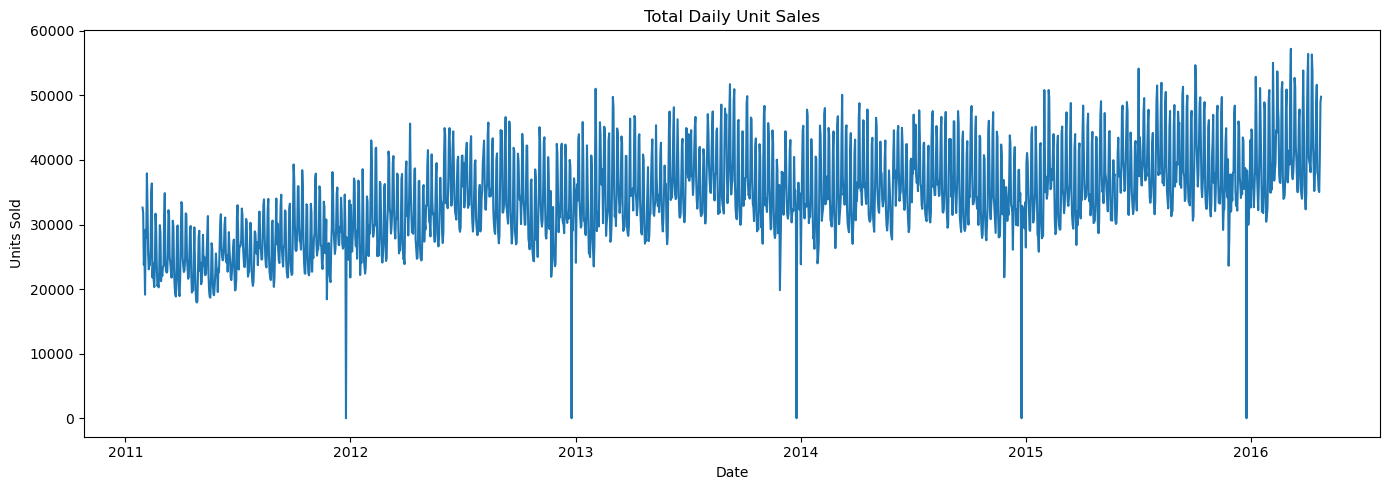

In [9]:
daily_total = (
    sales[day_cols]
    .sum(axis=0)
    .rename("sales")
    .reset_index()
    .rename(columns={"index": "d"})
)

#Merge dates:

daily_total = daily_total.merge(
    train_calendar,
    on="d",
    how="left"
)

#Check:

display(daily_total.head())

#Plot:

plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["date"],
    daily_total["sales"]
)

plt.title("Total Daily Unit Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

## 6. Smoothing data

Look for:

long-term growth
abrupt changes
volatility
recurring peaks
potential seasonality

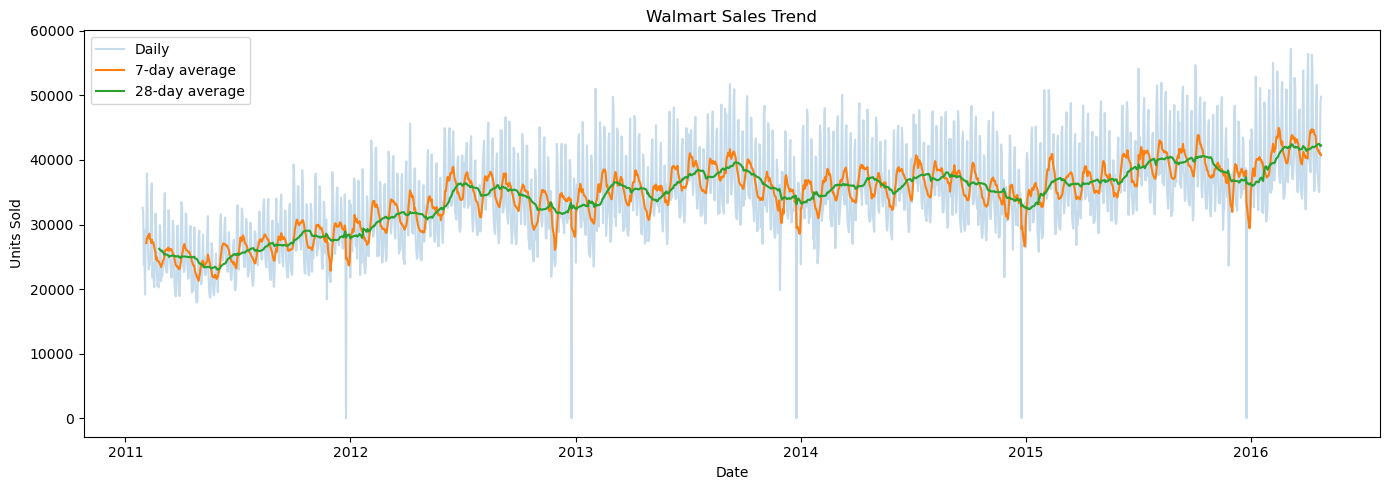

In [10]:
daily_total["rolling_7"] = (
    daily_total["sales"]
    .rolling(7)
    .mean()
)

daily_total["rolling_28"] = (
    daily_total["sales"]
    .rolling(28)
    .mean()
)
plt.figure(figsize=(14, 5))

plt.plot(
    daily_total["date"],
    daily_total["sales"],
    alpha=0.25,
    label="Daily"
)

plt.plot(
    daily_total["date"],
    daily_total["rolling_7"],
    label="7-day average"
)

plt.plot(
    daily_total["date"],
    daily_total["rolling_28"],
    label="28-day average"
)

plt.title("Walmart Sales Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Seasonality

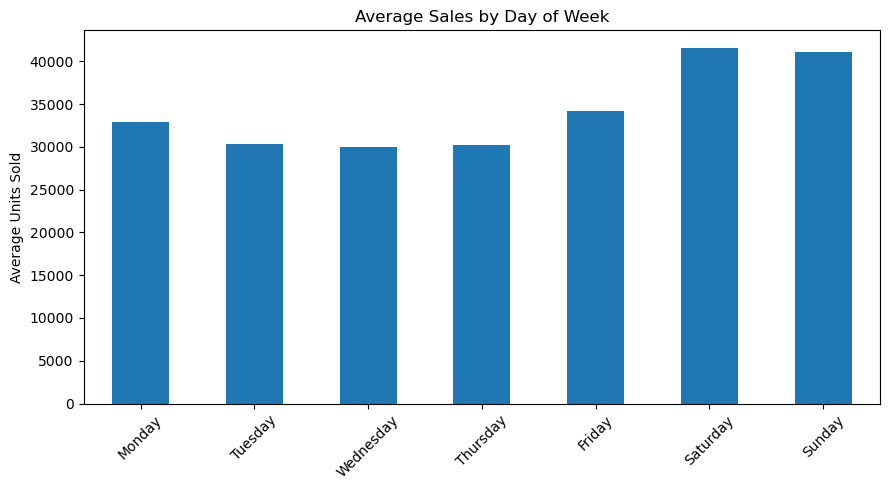

weekday
Monday       0.956857
Tuesday      0.884504
Wednesday    0.874055
Thursday     0.879734
Friday       0.996847
Saturday     1.210072
Sunday       1.197930
Name: SalesIndex, dtype: float64

In [11]:
weekday_sales = (
    daily_total
    .groupby("weekday")["sales"]
    .mean()
)


weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(
    weekday_order
)


plt.figure(figsize=(9, 5))

weekday_sales.plot(
    kind="bar"
)

plt.title("Average Sales by Day of Week")
plt.xlabel("")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


weekday_index = (
    weekday_sales
    / weekday_sales.mean()
)

display(
    weekday_index.rename(
        "SalesIndex"
    )
)

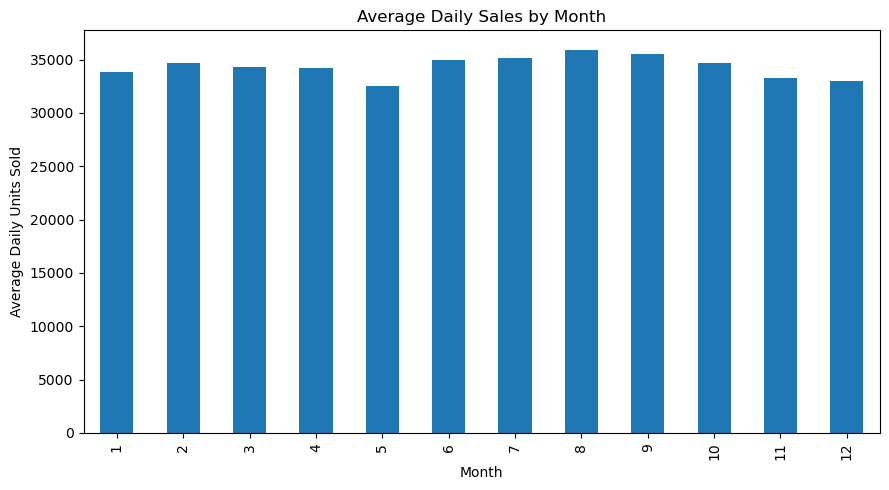

In [12]:
daily_total["month"] = (
    daily_total["date"].dt.month
)

monthly_pattern = (
    daily_total
    .groupby("month")["sales"]
    .mean()
)
plt.figure(figsize=(9, 5))

monthly_pattern.plot(
    kind="bar"
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Daily Units Sold")

plt.tight_layout()
plt.show()

## 8. Demand

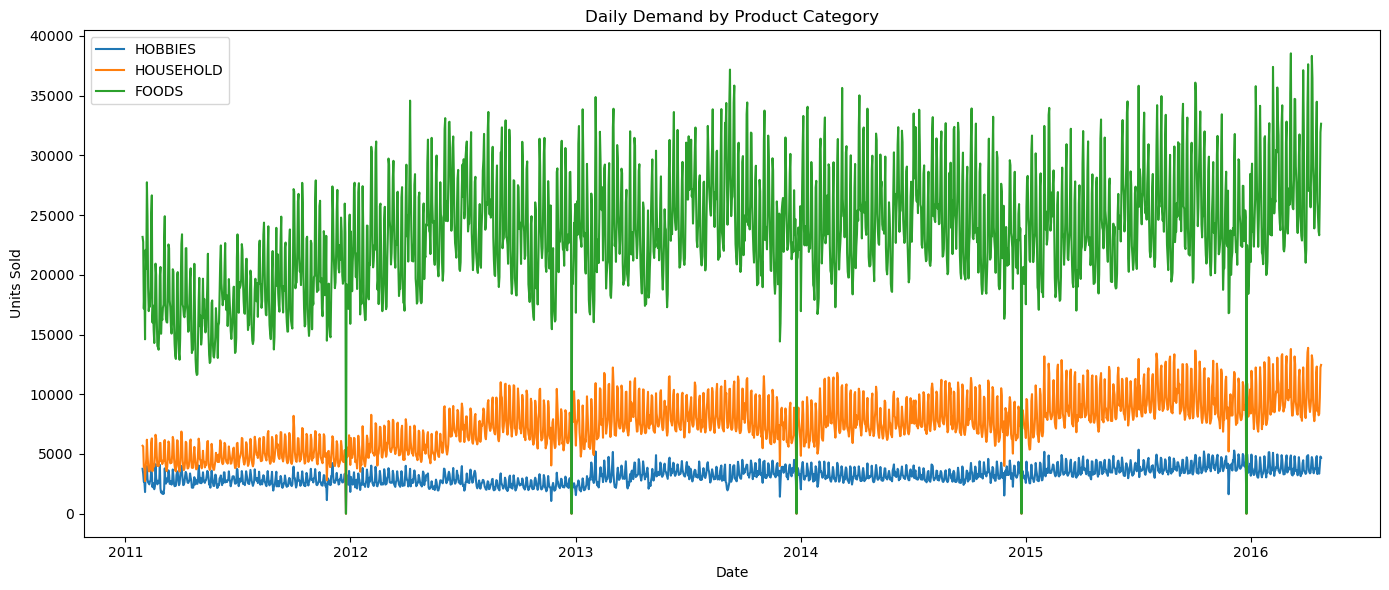

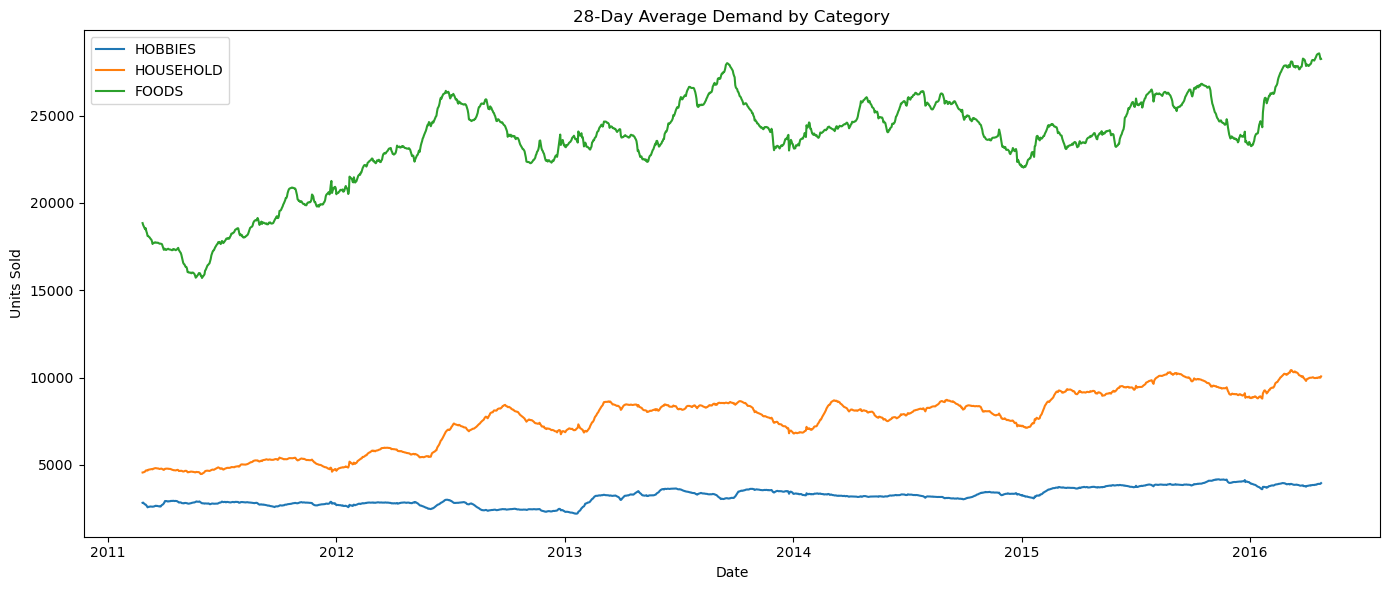

,Units,Share
cat_id,,
FOODS,45089939,0.686348
HOUSEHOLD,14480670,0.220421
HOBBIES,6124800,0.093230


In [13]:
category_sales = (
    sales
    .groupby("cat_id")[day_cols]
    .sum()
)


category_daily = (
    category_sales
    .T
    .reset_index()
    .rename(columns={"index": "d"})
)


category_daily = category_daily.merge(
    train_calendar[["d", "date"]],
    on="d",
    how="left"
)


plt.figure(figsize=(14, 6))

for category in sales["cat_id"].unique():

    plt.plot(
        category_daily["date"],
        category_daily[category],
        label=category
    )

plt.title("Daily Demand by Product Category")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

#Probably more useful with smoothing:

plt.figure(figsize=(14, 6))

for category in sales["cat_id"].unique():

    rolling = (
        category_daily[category]
        .rolling(28)
        .mean()
    )

    plt.plot(
        category_daily["date"],
        rolling,
        label=category
    )

plt.title("28-Day Average Demand by Category")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.tight_layout()
plt.show()

#Now investigate relative importance:

category_totals = (
    sales
    .groupby("cat_id")[day_cols]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

category_share = (
    category_totals
    / category_totals.sum()
)

display(
    pd.DataFrame({
        "Units": category_totals,
        "Share": category_share
    })
)